<a href="https://colab.research.google.com/github/leonardomenezes10/Fundamentos/blob/main/notebooks/OCDE/OECD_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução ao Pensamento computacional

## Ferramentas/Serviços utilizados

- Google Colab (notebook com codigo)
- Github (rede social de código)
- Git (programa de versionamento de código)


## Pilares
- Decomposição
- Abstração
- Identificação de padrões
- Lógica


## Noções Gerais

- Exemplos a partir de coleta de dados
  - Site MRE - Notas de imprensa
    - [x] Link do site: https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa
    - [x] Entender a estrutura da fonte de informação
    - [ ] Realizar a coleta
    - [ ] Inserir as informações em um banco de dados
    - [ ] Utilizar as informações (analise de dados)


### Padrão de paginação das notas de imprensa
  - https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=0
   - https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=30
   - Pagina final (10/02/2026): 6210



## Importação de bibliotecas/pogramas utilizados neste arquivo

In [1]:
!pip install tinydb

In [2]:
# programas/bibliotecas utilizados no script/codigo
import httpx # Responsável pelas requisições web
from bs4 import BeautifulSoup # Responsável por realizar o web scraping (coletar os dados)
from tinydb import TinyDB, Query

## Criação do banco json

In [3]:
def inserir_no_banco(dados, link_noticia):
  arquivo_banco_dados = "nota_OECD.json"
  db = TinyDB(arquivo_banco_dados)


  # Evitar dados repetidos no banco
  Buscar = Query()
  verificar_link = db.contains(Buscar.link == link_noticia)

  if not verificar_link:
    print("Inserindo nova informação no banco")
    db.insert(dados)
  else:
    print("Link já existe no banco. Esta informação não será inserida novamente")

In [4]:
for x in range (1, 23):
  paginas = (f'https://oecd.ai/en/wonk?page={x}')
  print(paginas)

https://oecd.ai/en/wonk?page=1
https://oecd.ai/en/wonk?page=2
https://oecd.ai/en/wonk?page=3
https://oecd.ai/en/wonk?page=4
https://oecd.ai/en/wonk?page=5
https://oecd.ai/en/wonk?page=6
https://oecd.ai/en/wonk?page=7
https://oecd.ai/en/wonk?page=8
https://oecd.ai/en/wonk?page=9
https://oecd.ai/en/wonk?page=10
https://oecd.ai/en/wonk?page=11
https://oecd.ai/en/wonk?page=12
https://oecd.ai/en/wonk?page=13
https://oecd.ai/en/wonk?page=14
https://oecd.ai/en/wonk?page=15
https://oecd.ai/en/wonk?page=16
https://oecd.ai/en/wonk?page=17
https://oecd.ai/en/wonk?page=18
https://oecd.ai/en/wonk?page=19
https://oecd.ai/en/wonk?page=20
https://oecd.ai/en/wonk?page=21
https://oecd.ai/en/wonk?page=22


In [5]:
# Variável e tipos de dados (string, lista, numero)

all_paginas_links = [] # Initialize as an empty list
for x in range (1, 23):
  url = (f'https://oecd.ai/en/wonk?page={x}')
  all_paginas_links.append(url) # Add each URL to the list

def acessa_pagina (link):
  print (f"Estamos na pagina:{link}")

  # Define headers para a requisição, simulando um navegador
  headers = {
      'User-Agent': "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36",
      'Accept-Language': 'en-US,en;q=0.9',
      'Accept-Encoding': 'gzip, deflate, br',
      'Connection': 'keep-alive',
  }

  timeout = httpx.Timeout(connect=20.0, read=30.0, write=20.0, pool=10.0)
  pag_web = httpx.get(link, headers=headers, timeout=timeout)
  bs = BeautifulSoup(pag_web, "html.parser")
  return bs

# loop for
# beautifulsoap >> find e find_all

# Now, iterate over the list of URLs
for pagina in all_paginas_links:
  pagina_inteira = acessa_pagina(pagina)
  lista_noticias = pagina_inteira.find_all("div", attrs={"class": "column is-12-mobile is-6-tablet is-4-desktop"})
  print(f"Quantidade de notícias encontradas: {len(lista_noticias)}")
  for noticia in lista_noticias:
    # titulo
    try:
      titulo = noticia.find("h4", attrs={"class": "title is-4 m-b-sm"}).text.strip()
      print(titulo)
    except:
        titulo = ""

    #link
    try:
      url_base = 'https://oecd.ai'
      link_noticia = url_base + noticia.a["href"]
      print(link_noticia)
    except:
      link_noticia = ""

    try:
      tema = noticia.find("span", attrs={"class": "has-text-link xsmall-meta"}).text.strip()
      print(tema)
    except:
      tema = ""

    # data
    data = noticia.find("p", attrs={"class": "xsmall-meta"}).text.strip()

    print(data)


    conteudo = acessa_pagina (link_noticia)
    paragrafos = conteudo.find("div", attrs={"class":"full-width"}).find_all("p")
    lista_paragrafos = []
    for paragrafo in paragrafos:
      lista_paragrafos.append(paragrafo.text.strip())
    print(lista_paragrafos)

    print("###")
    #função para inserir dados coletados no banco
    dados = {
        "titulo": titulo,
        "link": link_noticia,
        "data": data,
        "num_nota": tema,
        "paragrafo": lista_paragrafos
    }
    inserir_no_banco(dados,link_noticia)

Estamos na pagina:https://oecd.ai/en/wonk?page=1


Some characters could not be decoded, and were replaced with REPLACEMENT CHARACTER.


Quantidade de notícias encontradas: 0
Estamos na pagina:https://oecd.ai/en/wonk?page=2


Some characters could not be decoded, and were replaced with REPLACEMENT CHARACTER.


Quantidade de notícias encontradas: 0
Estamos na pagina:https://oecd.ai/en/wonk?page=3


...

Quantidade de notícias encontradas: 0
Estamos na pagina:https://oecd.ai/en/wonk?page=21


Some characters could not be decoded, and were replaced with REPLACEMENT CHARACTER.


Quantidade de notícias encontradas: 0
Estamos na pagina:https://oecd.ai/en/wonk?page=22


Some characters could not be decoded, and were replaced with REPLACEMENT CHARACTER.


Quantidade de notícias encontradas: 0


# Transformar banco json e dataframe

- pre-analise - entendimento geral sobre o dataframe

In [6]:
import pandas as pd
import json

## Abrindo o rquivo json
with open("nota_OECD.json") as f:
  raw = json.load(f)

df = pd.DataFrame.from_dict(raw["_default"], orient="index")

df


FileNotFoundError: [Errno 2] No such file or directory: 'nota_OECD.json'

In [ ]:
# saber quantidade de linhas e colunas do dataframe
df.shape

(256, 5)

In [ ]:
# saber colunas disponiveis
df.columns

Index(['titulo', 'link', 'data', 'num_nota', 'paragrafo'], dtype='object')

In [ ]:
# selecionar uma coluna em especifico
df["titulo"]

,titulo
1,AI for inclusive and resilient agri-food syste...
2,The OECD AI Policy Toolkit: Better AI policies...
3,Establishing the shared foundations for collec...
4,The European Union is deploying AI across stra...
5,Designing transparency for government AI: Insi...
...,...
252,Japan’s AI Utilization Guidelines: an initiati...
253,The OECD Network of Experts on AI: Moving from...
254,The IDB is bringing responsible and ethical AI...
255,Three habits to cultivate when converting ethi...


In [ ]:

# delimitar colunas do dataframe
df_delimitado = df[["titulo", "data"]]
df_delimitado

,titulo,data
1,AI for inclusive and resilient agri-food syste...,"June 5, 2026 — 8 min read"
2,The OECD AI Policy Toolkit: Better AI policies...,"June 3, 2026 — 3 min read"
3,Establishing the shared foundations for collec...,"May 21, 2026 — 8 min read"
4,The European Union is deploying AI across stra...,"May 19, 2026 — 6 min read"
5,Designing transparency for government AI: Insi...,"April 14, 2026 — 5 min read"
...,...,...
252,Japan’s AI Utilization Guidelines: an initiati...,"June 10, 2020 — 2 min read"
253,The OECD Network of Experts on AI: Moving from...,"June 8, 2020 — 14 min read"
254,The IDB is bringing responsible and ethical AI...,"June 3, 2020 — 4 min read"
255,Three habits to cultivate when converting ethi...,"May 11, 2020 — 4 min read"


In [ ]:

# primeiras (head), ultimas (tail) e linhas aleatórias (sample)
df.head(10)

,titulo,link,data,num_nota,paragrafo
1,AI for inclusive and resilient agri-food syste...,https://oecd.ai/en/wonk/ai-inclusive-and-resil...,"June 5, 2026 — 8 min read",Government,[Global agri-food systems are under growing st...
2,The OECD AI Policy Toolkit: Better AI policies...,https://oecd.ai/en/wonk/the-oecd-ai-policy-too...,"June 3, 2026 — 3 min read",Government,[Artificial intelligence (AI) is both a techno...
3,Establishing the shared foundations for collec...,https://oecd.ai/en/wonk/establishing-the-share...,"May 21, 2026 — 8 min read",Business,"[Emerging AI capabilities in coding, tool util..."
4,The European Union is deploying AI across stra...,https://oecd.ai/en/wonk/the-european-union-is-...,"May 19, 2026 — 6 min read",Intergovernmental,"[Across major economies, trustworthy artificia..."
5,Designing transparency for government AI: Insi...,https://oecd.ai/en/wonk/uk-algorithmic-transpa...,"April 14, 2026 — 5 min read",Government,"[In countries around the world, the public sec..."
6,Rethinking AI data: From scraping to sustainab...,https://oecd.ai/en/wonk/rethinking-ai-data-fro...,"March 31, 2026 — 6 min read",Intergovernmental,[As our daily activities become more digitised...
7,"To be truly participative, stakeholder involve...",https://oecd.ai/en/wonk/participative-stakehol...,"March 24, 2026 — 8 min read",Academia,[Participatory AI initiatives are meant to bri...
8,Why AI Sandboxes matter for responsible innova...,https://oecd.ai/en/wonk/sandboxes-matter-respo...,"March 18, 2026 — 10 min read",Intergovernmental,[Among the various tools available to policyma...
9,Can we create a clear understanding of what ag...,https://oecd.ai/en/wonk/what-agentic-ai-is-and...,"March 3, 2026 — 4 min read",Intergovernmental,[AI agents and agentic AI based on large langu...
10,Deadline extension 20 March: Global call for ‘...,https://oecd.ai/en/wonk/call-ai-in-gov,"March 1, 2026 — 4 min read",Intergovernmental,[While artificial intelligence is being increa...


In [ ]:
df.describe(include="all")

,titulo,link,data,num_nota,paragrafo
count,256,256,256,256,256
unique,256,256,253,9,256
top,AI for inclusive and resilient agri-food syste...,https://oecd.ai/en/wonk/ai-inclusive-and-resil...,"March 8, 2023 — 7 min read",Intergovernmental,[Global agri-food systems are under growing st...
freq,1,1,2,97,1


In [ ]:
df.isnull().sum()

,0
titulo,0
link,0
data,0
num_nota,0
paragrafo,0


### Tratamento de Dados e Visualização

Agora que entendemos a estrutura, vamos preparar os dados para extrair insights visuais. Um passo comum é converter colunas de texto em formatos que o computador entenda como 'tempo' (datetime) e criar gráficos.

In [ ]:
# 1. Converter a coluna de data para o formato datetime do Pandas
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True)

# 2. Contar quantas notícias temos por dia
noticias_por_dia = df['data_dt'].value_counts().sort_index()

display(noticias_por_dia)

/tmp/ipykernel_31557/1818697635.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True)


DateParseError: Unknown datetime string format, unable to parse: June 5, 2026 — 8 min read, at position 0

#### Visualizando o Volume de Publicações

Vamos usar a biblioteca `matplotlib` (que já vem no ambiente) para criar um gráfico de barras simples.

In [ ]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(10, 5))
noticias_por_dia.plot(kind='bar', color='skyblue')

# Adicionando títulos e rótulos
plt.title('Quantidade de Notas à Imprensa por Data')
plt.xlabel('Data da Publicação')
plt.ylabel('Número de Notas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

NameError: name 'noticias_por_dia' is not defined

<Figure size 1000x500 with 0 Axes>

#### Analisando Palavras-Chave nos Títulos

Uma técnica simples de análise de texto para iniciantes é verificar a frequência de certas palavras-chave (como nomes de países).

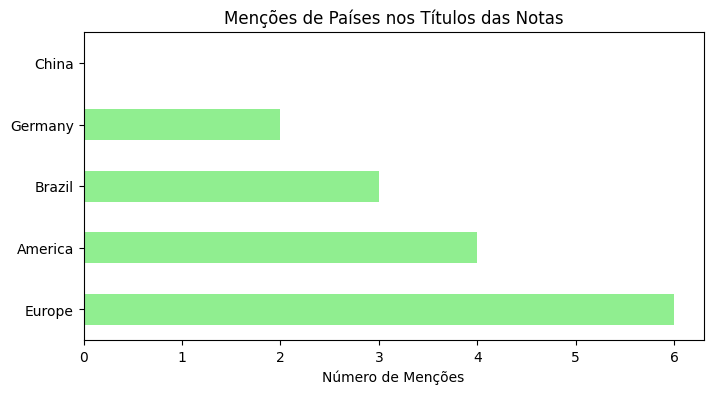

In [ ]:
paises = ['China', 'Germany', 'Europe', 'Brazil', 'America']
frequencia = {}

for pais in paises:
    # Conta em quantos títulos a palavra aparece
    frequencia[pais] = df['titulo'].str.contains(pais, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções de Países nos Títulos das Notas')
plt.xlabel('Número de Menções')
plt.show()

---

# 📊 Visualização avançada dos dados

Nesta parte vamos:

1. **Preparar** os dados (corrigir tipos, criar colunas auxiliares)
2. **Buscar** por termos e palavras-chave (no título e no corpo da nota)
3. **Analisar** frequência de termos (países, temas, organizações)
4. **Visualizar** o volume de publicações no tempo
5. **Acompanhar** um tema específico ao longo do tempo
6. **Gerar** nuvens de palavras (word cloud)
7. **Examinar** o tamanho das notas
8. **Descobrir** co-ocorrências (quais países aparecem juntos)


## 1. Preparação dos dados

Antes de visualizar, precisamos arrumar algumas coisas:

- A coluna `data` está como **texto** (`"22/04/2026"`). Vamos transformar em **datetime** para conseguir agrupar por mês, dia da semana, etc.
- A coluna `paragrafo` contém **listas** de strings — por isso `df.duplicated()` deu erro mais acima. Vamos juntar os parágrafos em um único texto na coluna `texto`.
- Vamos criar uma coluna `texto_completo` com título + corpo, em minúsculas, para facilitar buscas case-insensitive.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafo'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['titulo'].fillna('') + ' ' + df['texto']).str.lower()

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafo'] = df['paragrafo'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de notas: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['titulo', 'data_dt', 'qtd_paragrafo', 'tamanho_texto']].head()


Total de notas: 256
Período: de NaT até NaT


/tmp/ipykernel_31557/3035891850.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')


,titulo,data_dt,qtd_paragrafo,tamanho_texto
1,AI for inclusive and resilient agri-food syste...,NaT,27,14093
2,The OECD AI Policy Toolkit: Better AI policies...,NaT,14,3632
3,Establishing the shared foundations for collec...,NaT,32,11827
4,The European Union is deploying AI across stra...,NaT,25,8841
5,Designing transparency for government AI: Insi...,NaT,18,6805


### 1.1 Verificar duplicatas

Como a coluna `paragrafo` é uma lista, ela quebra o `df.duplicated()`. Solução: verificar duplicatas só nas colunas que importam (link, título).


In [ ]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df.duplicated(subset=['titulo']).sum())


Duplicatas por link: 0
Duplicatas por título: 0


## 2. 🔍 Busca por termos e palavras-chave

A busca anterior só olhava o **título**. Vamos criar uma função que busca no **título e/ou no corpo** da nota, mostrando quantas notas mencionam o termo e permitindo ver os resultados.


In [ ]:
def buscar_termo(termo, onde='completo', mostrar=5):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)
        mostrar (int): quantos resultados imprimir

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df)} ({len(resultado)/len(df)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.head(mostrar).iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['titulo']}")

    if len(resultado) > mostrar:
        print(f"  ... e mais {len(resultado) - mostrar} nota(s)")

    return resultado


# Exemplos de uso:
res = buscar_termo('China', onde='completo', mostrar=5)


🔎 Termo: 'China'  |  Onde: completo
📌 Notas encontradas: 24 de 256 (9.4%)
------------------------------------------------------------
  • [?] Can mid-sized economies come together to build frontier AI?
  • [?] Sovereign AI for assistive and public technologies: How policymakers can reinforce critical digital capacities
  • [?] AI openness: Balancing innovation, transparency and risk in open-weight models
  • [?] Strengthening global AI Safety: A perspective on the Singapore Consensus
  • [?] Unpacking the ‘AI wardrobe’: How national policies are shaping the future of AI
  ... e mais 19 nota(s)


In [ ]:
# Buscar só no título
buscar_termo('China', onde='titulo', mostrar=5)


🔎 Termo: 'China'  |  Onde: titulo
📌 Notas encontradas: 0 de 256 (0.0%)
------------------------------------------------------------


,titulo,link,data,num_nota,paragrafo,data_dt,texto,texto_completo,ano_mes,dia_semana,tamanho_texto,qtd_paragrafo


In [ ]:
# Buscar uma expressão composta
buscar_termo('China', onde='completo', mostrar=5)


🔎 Termo: 'China'  |  Onde: completo
📌 Notas encontradas: 24 de 256 (9.4%)
------------------------------------------------------------
  • [?] Can mid-sized economies come together to build frontier AI?
  • [?] Sovereign AI for assistive and public technologies: How policymakers can reinforce critical digital capacities
  • [?] AI openness: Balancing innovation, transparency and risk in open-weight models
  • [?] Strengthening global AI Safety: A perspective on the Singapore Consensus
  • [?] Unpacking the ‘AI wardrobe’: How national policies are shaping the future of AI
  ... e mais 19 nota(s)


,titulo,link,data,num_nota,paragrafo,data_dt,texto,texto_completo,ano_mes,dia_semana,tamanho_texto,qtd_paragrafo
15,Can mid-sized economies come together to build...,https://oecd.ai/en/wonk/can-mid-sized-economie...,"December 16, 2025 — 6 min read",Civil society,[Conventional wisdom presents mid-sized econom...,NaT,Conventional wisdom presents mid-sized economi...,can mid-sized economies come together to build...,NaT,NaN,9705,27
33,Sovereign AI for assistive and public technolo...,https://oecd.ai/en/wonk/sovereign-ai-for-assis...,"September 5, 2025 — 8 min read",Civil society,[Along with many AI roboticists and other EU t...,NaT,Along with many AI roboticists and other EU te...,sovereign ai for assistive and public technolo...,NaT,NaN,13845,31
35,"AI openness: Balancing innovation, transparenc...",https://oecd.ai/en/wonk/balancing-innovation-t...,"August 28, 2025 — 6 min read",Intergovernmental,"[In August 2025, OpenAI announced GPT-OSS, a f...",NaT,"In August 2025, OpenAI announced GPT-OSS, a fa...","ai openness: balancing innovation, transparenc...",NaT,NaN,7282,24
44,Strengthening global AI Safety: A perspective ...,https://oecd.ai/en/wonk/strengthening-global-a...,"June 5, 2025 — 5 min read",Government,[As artificial intelligence (AI) technologies ...,NaT,As artificial intelligence (AI) technologies a...,strengthening global ai safety: a perspective ...,NaT,NaN,6107,17
79,Unpacking the ‘AI wardrobe’: How national poli...,https://oecd.ai/en/wonk/ai-wardrobe-national-p...,"October 30, 2024 — 7 min read",Academia,[Grand pronouncements about artificial intelli...,NaT,Grand pronouncements about artificial intellig...,unpacking the ‘ai wardrobe’: how national poli...,NaT,NaN,11198,27
104,Responsible science communication can be a cat...,https://oecd.ai/en/wonk/responsible-science-co...,"March 25, 2024 — 6 min read",Business,[In an era of rapid scientific advancements an...,NaT,In an era of rapid scientific advancements and...,responsible science communication can be a cat...,NaT,NaN,8351,20
107,The AI data scraping challenge: How can we pr...,https://oecd.ai/en/wonk/data-scraping-responsibly,"March 5, 2024 — 8 min read",Academia,[Society faces an urgent and complex artificia...,NaT,Society faces an urgent and complex artificial...,the ai data scraping challenge: how can we pr...,NaT,NaN,12246,26
122,"For disabilities and designated groups, the Di...",https://oecd.ai/en/wonk/disabilities-designate...,"December 7, 2023 — 9 min read",Civil society,"[Following the Bletchley Declaration, governme...",NaT,"Following the Bletchley Declaration, governmen...","for disabilities and designated groups, the di...",NaT,NaN,15231,35
126,Accelerating science could be the most valuabl...,https://oecd.ai/en/wonk/accelerating-science,"November 21, 2023 — 8 min read",Intergovernmental,[The OECD’s recent publication – Artificial In...,NaT,The OECD’s recent publication – Artificial Int...,accelerating science could be the most valuabl...,NaT,NaN,11790,28
128,How countries are implementing the OECD Princi...,https://oecd.ai/en/wonk/national-policies-2,"October 31, 2023 — 9 min read",Intergovernmental,[Since signing on to the OECD AI Principles in...,NaT,Since signing on to the OECD AI Principles in ...,how countries are implementing the oecd princi...,NaT,NaN,10534,30


## 3. 📈 Frequência de vários termos comparados

Vamos generalizar a análise: em vez de fixar 5 países, comparamos qualquer lista de termos de interesse (países, organizações, temas) — buscando no texto **completo** (não só no título).


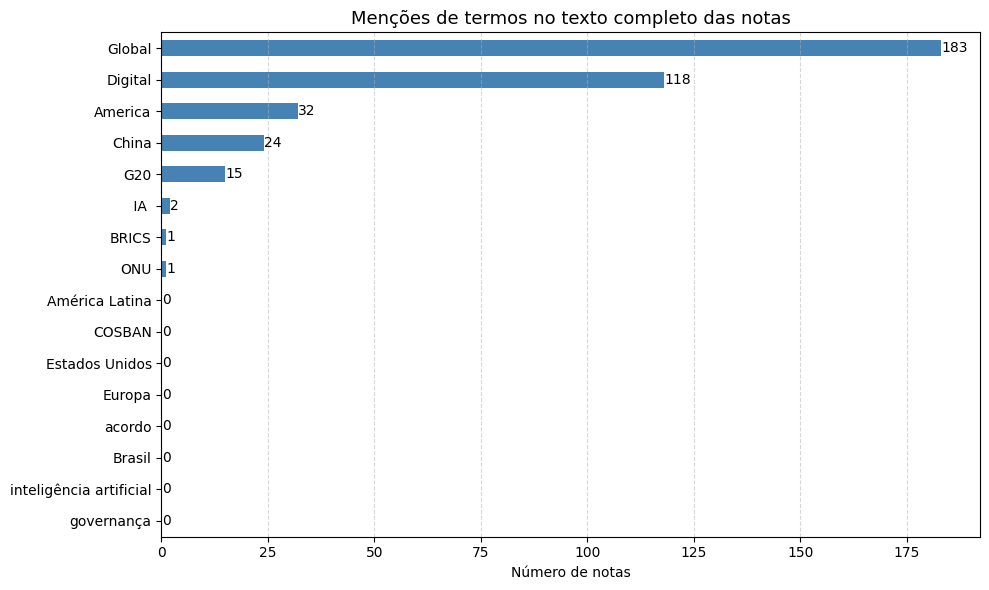

In [ ]:
def frequencia_termos(lista_termos, onde='completo'):
    """Conta em quantas notas cada termo da lista aparece."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    freq = {}
    for termo in lista_termos:
        freq[termo] = df[coluna].str.contains(termo, case=False, na=False, regex=False).sum()
    return pd.Series(freq).sort_values(ascending=True)


# Lista mais ampla de países e temas
termos_interesse = [
    'governança', ' IA ', 'inteligência artificial', 'Brasil', 'Global', 'acordo' ,
    'BRICS', 'China', 'G20', 'América Latina', 'America',
    'Digital', 'ONU', 'Europa', 'Estados Unidos', 'Europa', 'COSBAN'
]

freq = frequencia_termos(termos_interesse, onde='completo')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
freq.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Menções de termos no texto completo das notas', fontsize=13)
ax.set_xlabel('Número de notas')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Anotar valores nas barras
for i, valor in enumerate(freq.values):
    ax.text(valor + 0.1, i, str(valor), va='center')

plt.tight_layout()
plt.show()


## 4. 🧠 Extração automática de palavras mais frequentes

Em vez de **definirmos** os termos, deixamos os dados falarem: quais palavras aparecem mais nos títulos? Para isso precisamos remover as **stopwords** (palavras muito comuns como "de", "da", "para") e palavras curtas.


Top 20 palavras nos TÍTULOS:
  data                      31
  governance                23
  global                    22
  intelligence              22
  artificial                20
  policy                    17
  work                      17
  responsible               16
  systems                   15
  trustworthy               15
  transparency              12
  framework                 12
  policies                  10
  risk                      10
  future                    10
  innovation                9
  insights                  8
  trust                     8
  approach                  8
  reporting                 8


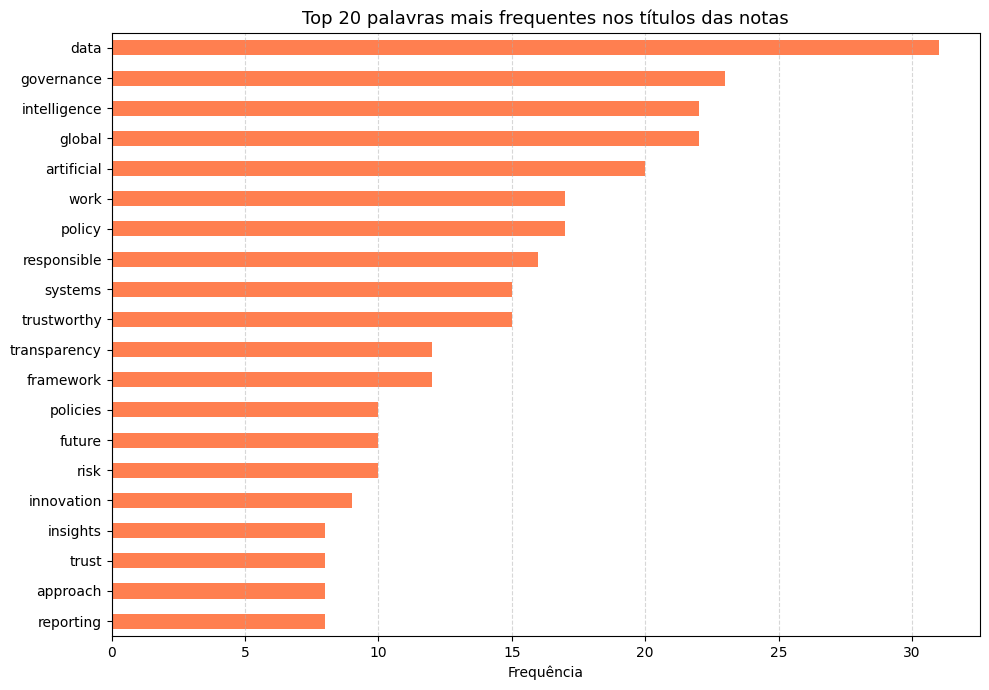

In [ ]:
import re
from collections import Counter

# Stopwords em português (lista pequena, suficiente para começar)
STOPWORDS_PT = {
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das', 'em', 'no', 'na', 'nos', 'nas',
    'e', 'ou', 'mas', 'que', 'se', 'por', 'para', 'com', 'sem',
    'oecd', 'from', 'what', 'with', 'pelo', 'pela', 'pelos', 'pelas',
    'é', 'são', 'foi', 'ser', 'estar', 'tem', 'ter', 'há',
    'sobre', 'entre', 'até', 'após', 'pela', 'pelo',
    'sua', 'seu', 'suas', 'seus', 'este', 'esta', 'isso', 'esse', 'essa',
    'nº', 'n°', 'nota', 'notas', 'imprensa', 'mais', 'como', 'lança', 'nova'
    'federal', 'evento'  # específicas do contexto
}


def palavras_mais_frequentes(serie_texto, top_n=20, min_tamanho=4):
    """Conta as palavras mais frequentes em uma coluna de texto."""
    todas_palavras = []
    for texto in serie_texto.dropna():
        # \w+ pega sequências de letras/números; flags re.UNICODE pra acentos
        palavras = re.findall(r'\b[a-záàâãéêíóôõúüç]+\b', texto.lower(), flags=re.UNICODE)
        palavras = [p for p in palavras if p not in STOPWORDS_PT and len(p) >= min_tamanho]
        todas_palavras.extend(palavras)
    return Counter(todas_palavras).most_common(top_n)


top_palavras = palavras_mais_frequentes(df['titulo'], top_n=20)
print("Top 20 palavras nos TÍTULOS:")
for palavra, contagem in top_palavras:
    print(f"  {palavra:25s} {contagem}")

# Gráfico
serie = pd.Series(dict(top_palavras)).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
serie.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 palavras mais frequentes nos títulos das notas', fontsize=13)
ax.set_xlabel('Frequência')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5. 🗓️ Análise temporal

O gráfico anterior ("notas por dia") fica difícil de ler quando há muitas datas. Vamos olhar em **agregações** mais úteis: por mês, por dia da semana, e por hora do dia.


IndexError: index 0 is out of bounds for axis 0 with size 0

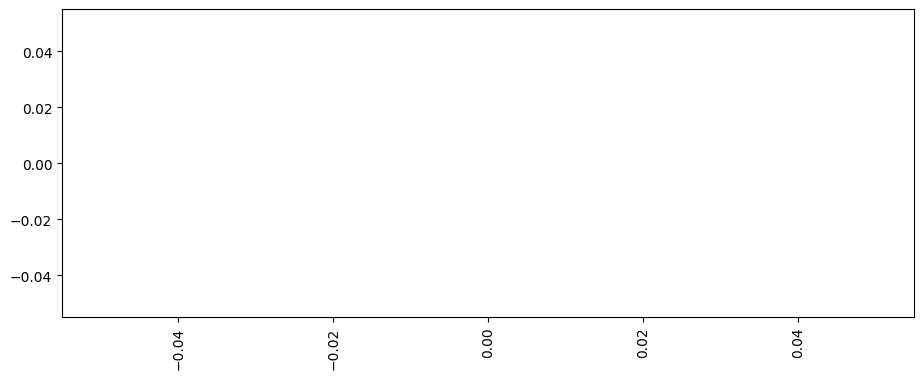

In [ ]:
# Notas por mês
notas_por_mes = df.groupby('ano_mes').size()

notas_por_mes

fig, ax = plt.subplots(figsize=(11, 4))
notas_por_mes.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Volume de notas por mês', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


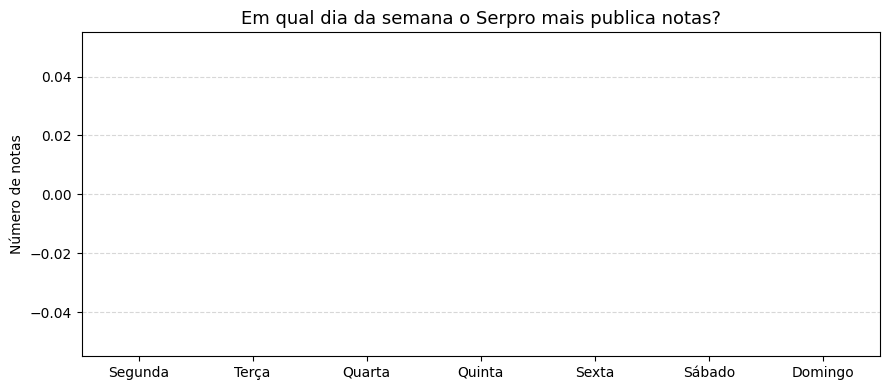

In [ ]:
# Notas por dia da semana (em português)
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traducao_dias = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

por_dia_semana = df['dia_semana'].value_counts().reindex(ordem_dias).fillna(0)
por_dia_semana.index = [traducao_dias[d] for d in por_dia_semana.index]

fig, ax = plt.subplots(figsize=(9, 4))
por_dia_semana.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Em qual dia da semana o Serpro mais publica notas?', fontsize=13)
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. 📅 Acompanhar um tema ao longo do tempo

Combinando busca por termo + análise temporal: como evoluiu a menção a um país ou tema ao longo dos meses?


/tmp/ipykernel_31557/977383167.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


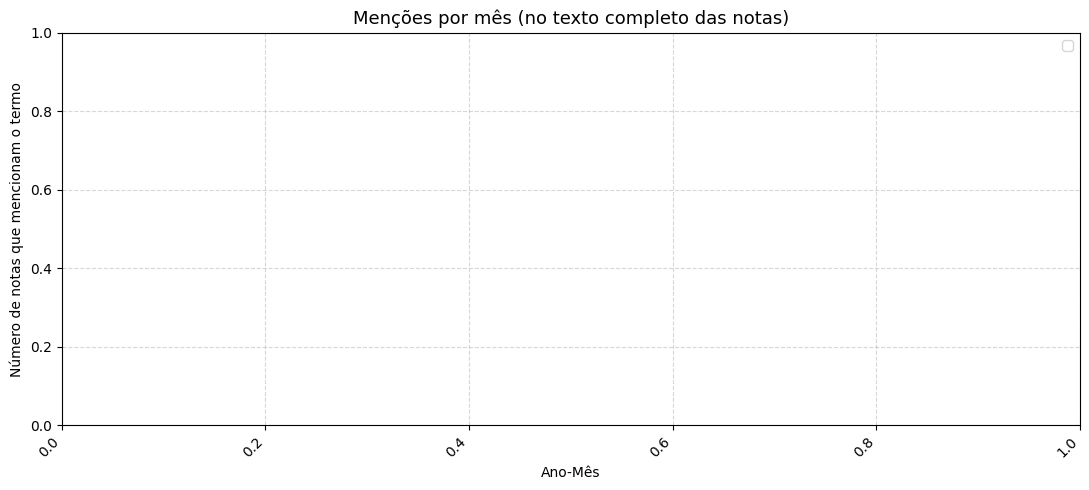

In [ ]:
def evolucao_termo(termo, onde='completo'):
    """Mostra quantas notas mencionam o termo por mês."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    return df[mascara].groupby('ano_mes').size()


# Comparar evolução de vários termos no tempo
termos_comparar = ['sovereignty', 'risk', 'America', 'China']

fig, ax = plt.subplots(figsize=(11, 5))
for termo in termos_comparar:
    serie = evolucao_termo(termo)
    if len(serie) > 0:
        serie.plot(ax=ax, marker='o', label=termo)

ax.set_title('Menções por mês (no texto completo das notas)', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas que mencionam o termo')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. ☁️ Nuvem de palavras (word cloud)

Forma visual e divertida de ver os termos mais frequentes — quanto maior a palavra, mais ela aparece.

> ⚠️ Precisa instalar a biblioteca `wordcloud` (rode a próxima célula uma vez).


In [ ]:
!pip install wordcloud -q


In [ ]:
from wordcloud import WordCloud

# Junta todos os títulos em um único texto gigante
texto_titulos = ' '.join(df['titulo'].dropna()).lower()

# Remove stopwords usando o set já definido
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS_PT,
    colormap='viridis',
    min_word_length=4,
    collocations=False,  # evita repetir bigramas
).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuvem de palavras dos títulos das notas', fontsize=14)
plt.tight_layout()
plt.show()


## 8. 📏 Tamanho das notas

Quanto texto o MRE costuma escrever em cada nota? Algumas notas são bem curtas (ex: cumprimentos), outras são longas (declarações conjuntas, etc.).


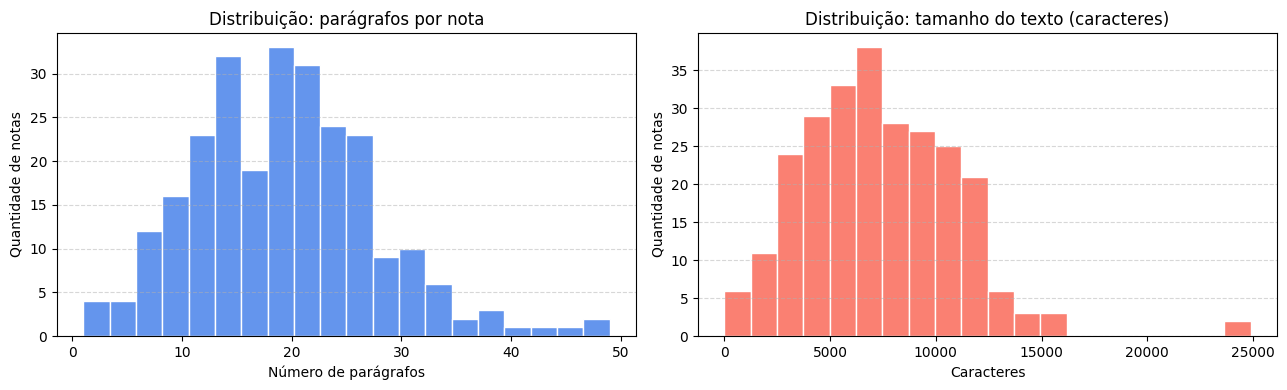


📊 Estatísticas:
       qtd_paragrafo  tamanho_texto
count          256.0          256.0
mean            19.2         7333.9
std              8.4         3572.8
min              1.0            0.0
25%             13.0         4762.0
50%             19.0         7079.5
75%             24.0         9670.5
max             49.0        24893.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de quantidade de parágrafos
df['qtd_paragrafo'].plot(kind='hist', bins=20, ax=axes[0], color='cornflowerblue', edgecolor='white')
axes[0].set_title('Distribuição: parágrafos por nota')
axes[0].set_xlabel('Número de parágrafos')
axes[0].set_ylabel('Quantidade de notas')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Histograma de tamanho do texto (em caracteres)
df['tamanho_texto'].plot(kind='hist', bins=20, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Distribuição: tamanho do texto (caracteres)')
axes[1].set_xlabel('Caracteres')
axes[1].set_ylabel('Quantidade de notas')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n📊 Estatísticas:")
print(df[['qtd_paragrafo', 'tamanho_texto']].describe().round(1))


## 9. 🔗 Co-ocorrência de países

Quais países aparecem **juntos** numa mesma nota? Isso revela parcerias diplomáticas e contextos compartilhados (ex: declarações conjuntas).


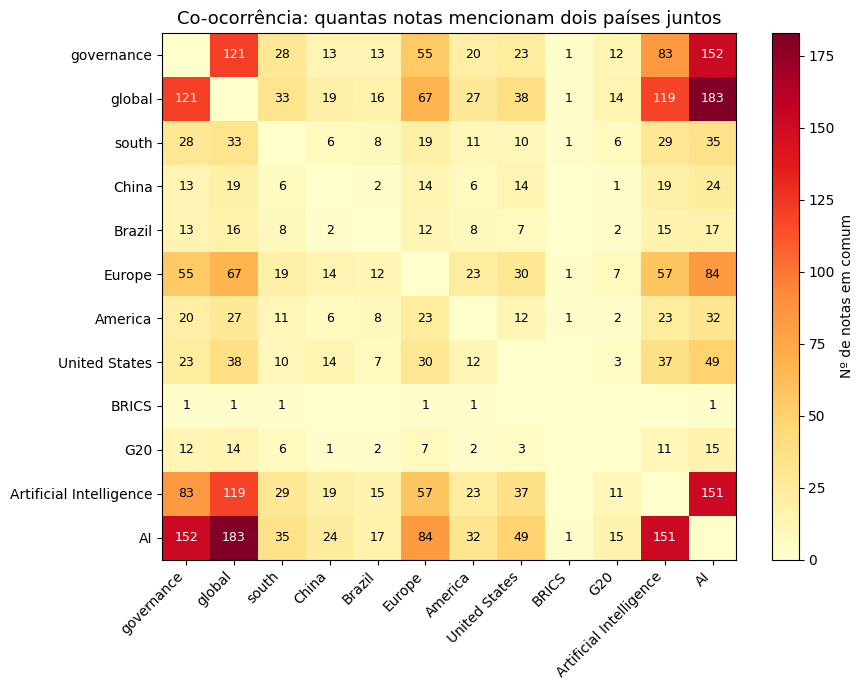

In [ ]:
import numpy as np

paises_analise = ['governance', 'global', 'south', 'China', 'Brazil', 'Europe', 'America',
                  'United States', 'BRICS', 'G20', 'Artificial Intelligence', 'AI']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    pais: df['texto_completo'].str.contains(pais, case=False, na=False, regex=False).astype(int)
    for pais in paises_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(paises_analise)))
ax.set_yticks(range(len(paises_analise)))
ax.set_xticklabels(paises_analise, rotation=45, ha='right')
ax.set_yticklabels(paises_analise)
ax.set_title('Co-ocorrência: quantas notas mencionam dois países juntos', fontsize=13)

# Anotar os valores nas células
for i in range(len(paises_analise)):
    for j in range(len(paises_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()
